# Principal Component Analysis (PCA)
Created by Marc Deisenroth and Yicheng Luo

Edited by Kris Lokere

We will implement the PCA algorithm using the projection perspective. We will first implement PCA, then apply it to the MNIST digit dataset.

Let's first import the packages we need for this week.

In [ ]:
# load libraries (DO NOT EDIT THIS CELL)
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

In [ ]:
# Load MNIST digits dataset (DO NOT EDIT THIS CELL)
from sklearn.datasets import fetch_openml
images, labels = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

In [ ]:
# how many digits are there?
N = 10 # <-- EDIT THIS LINE
print(N)

10


Now, let's plot a digit from the dataset:

In [ ]:
# each image is a vector of length 784
# this is a 'flattened' version of a hand-drawn 28x28 pixel image
# we will process them as vectors, but for display purposes, we need to reshape them

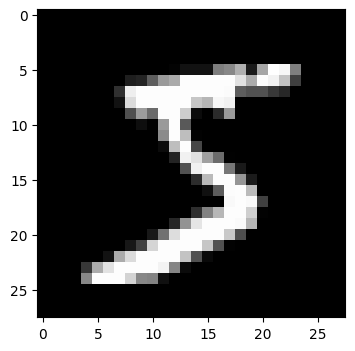

In [ ]:
plt.figure(figsize=(4,4))
plt.imshow(images[0].reshape(28,28), cmap='gray')
plt.show()

## Data Preprocessing

Before we implement PCA, we will need to do some data preprocessing. In this assessment, some of them
will be implemented by you, others we will take care of. However, when you are working on real world problems, you will need to do all these steps by yourself.

The preprocessing steps we will do are
1. Convert unsigned integer 8 (uint8) encoding of pixels to a floating point number between 0 and 1.
2. Subtract from each image the mean $\boldsymbol \mu$.
3. Scale each dimension of each image by $\frac{1}{\sigma}$ where $\sigma$ is the stardard deviation.

The steps above ensure that our images will have zero mean and one variance. These preprocessing
steps are also known as [Data Normalization or Feature Scaling](https://en.wikipedia.org/wiki/Feature_scaling).

In [ ]:
# what are the min and max pixel values (across the entire dataset)
np.min(images), np.max(images)

(np.int64(0), np.int64(255))

In [ ]:
def normalize(X):
    """Normalize the given dataset X
    Args:
        X: ndarray, dataset

    Returns:
        (Xbar, mean, std): tuple of ndarray, Xbar is the normalized dataset
        with mean 0 and standard deviation 1; mean and std are the
        mean and standard deviation respectively.

    Note:
        You will encounter dimensions where the standard deviation is
        zero, for those when you do normalization the normalized data
        will be NaN. Handle this by setting using `std = 1` for those
        dimensions when doing normalization.
    """
    N, D = X.shape
    X = X.astype(np.float64)/ 255.0
    mu = np.mean(X, axis=0) # <-- EDIT THIS, compute the mean of X
    std =  np.std(X, axis=0) # <-- EDIT THIS, compute the standard deviation across axis 0
    std_filled = std.copy()
    std_filled[std==0] = 1. # if the std was 0, we set it to 1 so that we won't divide by 0
    Xbar = (X - mu) / std_filled   # <-- EDIT THIS, compute the normalized data Xbar
    return Xbar, mu, std

In [ ]:
# run the normalization of the images dataset
Xbar, mu, std = normalize(images)
Xbar.shape, mu.shape, std.shape

((70000, 784), (784,), (784,))

In [ ]:
# Now what are the min and max pixel values (across the entire dataset)
np.min(Xbar), np.max(Xbar)

(np.float64(-1.2778690230072927), np.float64(264.5732412773447))

In [ ]:
# Sanity Check
print(np.mean(Xbar, axis=0)[:10])
print(np.std(Xbar[:, std > 0], axis=0)[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## PCA

Now we will implement PCA. Before we do that, let's pause for a moment and
think about the steps for performing PCA. Assume that we are performing PCA on
some dataset $\boldsymbol X$ for $M$ principal components.
We then need to perform the following steps, which we break into parts:

1. Data normalization (`normalize`).
2. Find eigenvalues and corresponding eigenvectors for the covariance matrix $S$.
   Sort by the largest eigenvalues and the corresponding eigenvectors (`eig`).
3. Calculate a projection matrix consisting of the top $n$ eigenvectors (`projection_matrix`)
4. Project the data $X$ using the projection matrix


In [ ]:
def eig(S):
    """Compute the eigenvalues and corresponding eigenvectors
        for the covariance matrix S.
    Args:
        S: ndarray, covariance matrix

    Returns:
        (eigvals, eigvecs): ndarray, the eigenvalues and eigenvectors (use np.linalg.eig())

    Note:
        the eigenvals and eigenvecs should be sorted in descending
        order of the eigen values. Use np.argsort() to find the indices
        of the sorted eigen values and use these indices to sort both
        eigen values and eigen vectors.
    """
    eigvals, eigvecs = np.linalg.eig(S)
    k = np.argsort(eigvals)[::-1]
    return eigvals[k], eigvecs[:,k] # <-- EDIT THIS to return the eigenvalues and corresponding eigenvectors

def projection_matrix(B):
    """Compute the projection matrix onto the space spanned by columns of `B`
    Args:
        B: ndarray of dimension (D, M), the basis for the subspace

    Returns:
        P: the projection matrix
    """
    P = B @ np.linalg.inv(B.T @ B) @ B.T # <-- EDIT THIS to compute the projection matrix
    return P

def PCA(X, num_components):
    """
    Args:
        X: ndarray of size (N, D), where D is the dimension of the data,
           and N is the number of datapoints
        num_components: the number of principal components to use.
    Returns:
        X_reconstruct: ndarray of the reconstruction
        of X from the first `num_components` principal components.
    """
    N, D = X.shape
    # your solution should take advantage of the functions you have implemented above.
    # calculate covariance matrix S
    S = 1.0/len(X) * X.T @ X # the data samples are in rows of X
    # calculate sorted eigenvalues and eigenvectors of S
    eig_vals, eig_vecs = eig(S)
    # keep the first num_components eigenvectors, collect them into a matrix B
    B = eig_vecs[:, :num_components] # <-- EDIT THIS
    # convert all eigenvectors to real, to avoid complex numbers from rounding
    B = np.real(B)
    # project the data onto the columns of B
    reconst_columns = projection_matrix(B) @ X.T
    # careful: result should have the same shape as X!
    return (projection_matrix(B) @ X.T).T   # <-- EDIT THIS to return the reconstruction of X


In [ ]:
# to save time we could run PCA on a smaller subset of the entire dataset
NUM_DATAPOINTS = 1000
X = Xbar[:NUM_DATAPOINTS]
X.shape

(1000, 784)

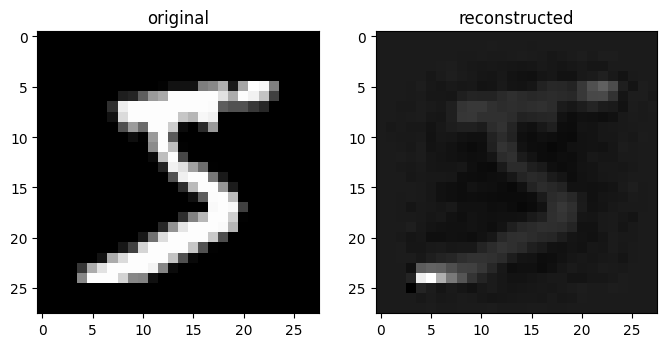

In [ ]:
# now let's run PCA on some data, using 200 components
reconst = PCA(X, 200)
# create two subplots
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8, 4))
# plot the original data
ax0.imshow(images[0].reshape(28,28), cmap='gray')
ax0.set_title('original')
# plot the reconstructed data
ax1.imshow(reconst[0].reshape(28,28), cmap='gray')
ax1.set_title('reconstructed')
plt.show()

In [ ]:
# the result does not look that good, even though we used many components to reconstruct
# what went wrong?
# we ran PCA on normalized data, so we need to "un-normalize" it before displaying!
img_reconst = np.zeros_like(reconst)
for i in range(reconst.shape[0]):
    img_reconst[i] = reconst[i] * std + mu # <-- EDIT THIS to scale back by std and restore mean mu
X.shape, reconst.shape, img_reconst.shape

((1000, 784), (1000, 784), (1000, 784))

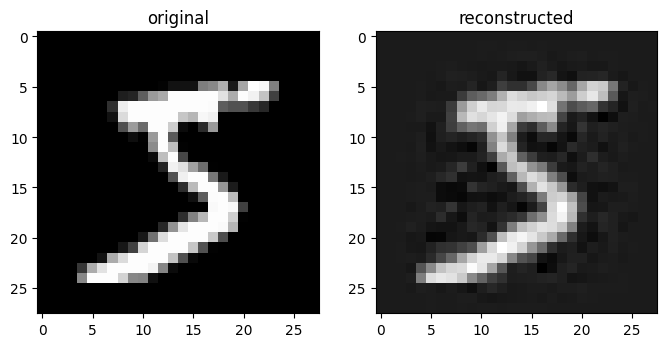

In [ ]:
# now display an original image side-by-side with an unnormalized reconstructed image
# EDIT THIS CELL to Display
# create two subplots
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8, 4))
# plot the original data
ax0.imshow(images[0].reshape(28,28), cmap='gray')
ax0.set_title('original')
# plot the reconstructed data
ax1.imshow(img_reconst[0].reshape(28,28), cmap='gray')
ax1.set_title('reconstructed')
plt.show()

The above result should look pretty good. But how do we quantify how good it is? Let's calculate MSE between two images.

We have provided a function in the next cell that computes the mean squared error (MSE), which will be useful for answering the question above.

In [ ]:
def mse(predict, actual):
    """Helper function for computing the mean squared error (MSE)"""
    return np.square(predict - actual).sum(axis=1).mean()

In [ ]:
loss = []
reconstructions = []
# iterate over different numbers of principal components, and compute the MSE
for num_component in range(1, 120):
    reconst = PCA(X, num_component)
    error = mse(reconst, X)
    reconstructions.append(reconst)
    print(f"\rn = {num_component}, reconstruction_error = {error}", end="")
    loss.append((num_component, error))

reconstructions = np.asarray(reconstructions)
reconstructions = reconstructions * std + mu # "unnormalize" the reconstructed image
loss = np.asarray(loss)

n = 119, reconstruction_error = 67.74635611677083

In [ ]:
reconstructions.shape

(119, 1000, 784)

In [ ]:
import pandas as pd
# create a table showing the number of principal components and MSE
pd.DataFrame(loss).head()

,0,1
0,1.0,686.056674
1,2.0,645.780536
2,3.0,610.925793
3,4.0,580.545985
4,5.0,555.276714


We can also put these numbers into perspective by plotting them.

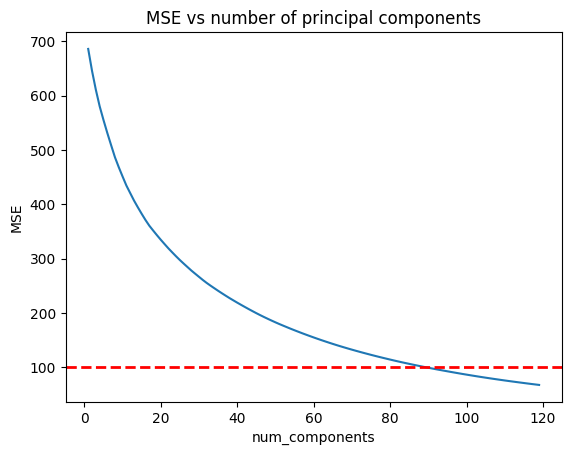

In [ ]:
fig, ax = plt.subplots()
ax.plot(loss[:,0], loss[:,1]);
ax.axhline(100, linestyle='--', color='r', linewidth=2)
ax.set(xlabel='num_components', ylabel='MSE', title='MSE vs number of principal components');

But _numbers dont't tell us everything_! Just what does it mean _qualitatively_ for the loss to decrease from around
$450.0$ to less than $100.0$?

Let's find out! In the next cell, we draw as the leftmost image the original digit. Then we show the reconstruction of the image on the right. We can select the image (i) and the number of components for reconstruction (k).

In [ ]:
@interact(i=(0, 10), k=(0,100))
def show_pca_digits(i=1,k=1):
    """Show the i th digit and its reconstruction"""
    plt.figure(figsize=(4,4))
    actual_sample = images[i].reshape(28,28)
    reconst_sample = reconstructions[k,i, :].reshape(28, 28)
    plt.imshow(np.hstack([actual_sample, reconst_sample]), cmap='gray')
    plt.show()

interactive(children=(IntSlider(value=1, description='i', max=10), IntSlider(value=1, description='k'), Output…

## Reconstruction Error related to Eigenvalues

In [ ]:
# calculate the loss again, for each number of components
# but save some memory by not saving the reconstructions themselves this time
loss = []
# iterate over number of principal components to use, and compute the MSE
for num_component in range(1, 400):
    reconst = PCA(X, num_component)
    error = mse(reconst, X)
    print(f"\rn = {num_component}, reconstruction_error = {error}", end="")
    loss.append((num_component, error))
loss = np.asarray(loss)

n = 399, reconstruction_error = 2.912000418159184

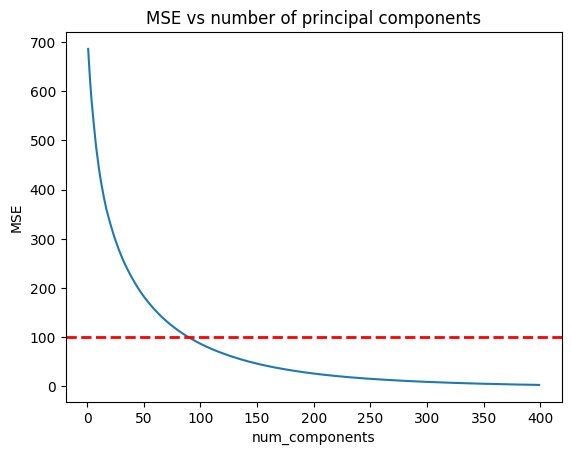

In [ ]:
fig, ax = plt.subplots()
ax.plot(loss[:,0], loss[:,1]);
ax.axhline(100, linestyle='--', color='r', linewidth=2)
ax.set(xlabel='num_components', ylabel='MSE', title='MSE vs number of principal components');

In [ ]:
# we think that this reconstruction loss should have something to do with the eigenvalues
# modify the PCA function to also return the eigenvalues

def new_PCA(X, num_components):
    """
    Args:
        X: ndarray of size (N, D), where D is the dimension of the data,
           and N is the number of datapoints
        num_components: the number of principal components to use.
    Returns:
        X_reconstruct: ndarray of the reconstruction
        of X from the first `num_components` principal components.
    """
    N, D = X.shape
    # repeat most code from the PCA() function that you wrote earlier # <-- EDIT THIS
    S = 1.0/N * X.T @ X
    eig_vals, eig_vecs = eig(S)
    B = np.real(eig_vecs[:, :num_components])
    X_reconstruct = (projection_matrix(B) @ X.T).T  # <-- EDIT THIS
    return eig_vals[:num_components], X_reconstruct # <-- EDIT THIS

In [ ]:
eig_vals, reconst = new_PCA(X, 400)

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


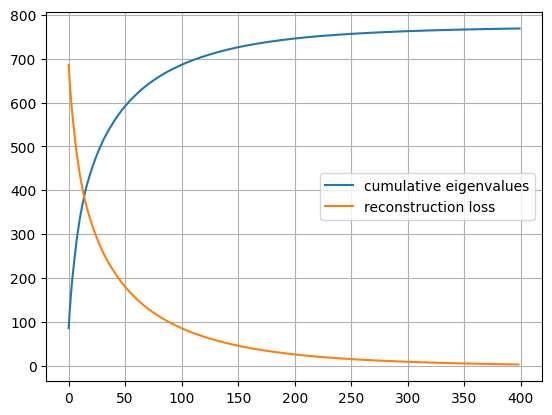

In [ ]:
# plot the cumulative eigenvalues
# alongside the loss (calculated earlier)
plt.plot(np.cumsum(eig_vals), label="cumulative eigenvalues")
plt.plot(loss[:,1], label="reconstruction loss")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# the two plots seem related
# can you perform an appropriate scaling / transforming on these two curves
# so that they become equal to each other?

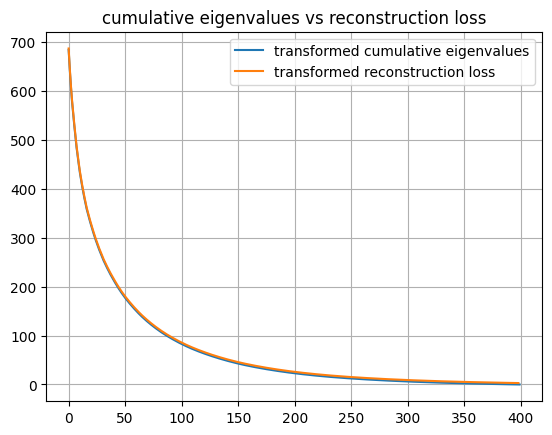

In [ ]:
total_variance = np.sum(eig_vals)
plt.plot(total_variance - np.cumsum(eig_vals), label="transformed cumulative eigenvalues")   # <-- EDIT THIS
plt.plot(loss[:,1], label="transformed reconstruction loss") # <-- EDIT THIS
plt.grid(True)
plt.legend()
plt.title("cumulative eigenvalues vs reconstruction loss") # <-- EDIT THIS
plt.show()